# 0. LOAD DATASET

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import zipfile
from pathlib import Path

import pandas as pd

In [ ]:
# 1. Tentukan path dataset ZIP
ZIP_PATH = "/content/drive/MyDrive/Project/idsc 2026/hillel-yaffe-glaucoma-dataset-hygd-a-gold-standard-annotated-fundus-dataset-for-glaucoma-detection-1.1.0.zip"

# Folder ekstraksi
EXTRACT_DIR = Path("/content/drive/MyDrive/Project/idsc 2026")

In [ ]:
# 2. Ekstrak ZIP
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    zf.extractall(EXTRACT_DIR)

print(f"Dataset extracted to: {EXTRACT_DIR.resolve()}")

Dataset extracted to: /content/drive/MyDrive/Project/idsc 2026


In [ ]:
# 3. Cari root folder dataset hasil ekstraksi
subdirs = [p for p in EXTRACT_DIR.iterdir() if p.is_dir()]
if len(subdirs) == 1:
    DATASET_ROOT = subdirs[0]
else:
    DATASET_ROOT = EXTRACT_DIR

print(f"Dataset root: {DATASET_ROOT.resolve()}")

Dataset root: /content/drive/MyDrive/Project/idsc 2026/hillel-yaffe-glaucoma-dataset-hygd-a-gold-standard-annotated-fundus-dataset-for-glaucoma-detection-1.1.0


memastikan script tetap jalan walau struktur ZIP sedikit berbeda

In [ ]:
# 4. Definisikan path penting
IMAGE_DIR = DATASET_ROOT / "Images"
LABEL_PATH = DATASET_ROOT / "Labels.csv"

print(f"Image directory exists: {IMAGE_DIR.exists()}")
print(f"Label file exists: {LABEL_PATH.exists()}")

Image directory exists: True
Label file exists: True


menentukan folder gambar dan file label

In [ ]:
# 5. Load label CSV
df = pd.read_csv(LABEL_PATH)

print("\nRaw dataframe shape:", df.shape)
print("\nRaw columns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())


Raw dataframe shape: (747, 5)

Raw columns:
['Image Name', 'Patient', 'Label', 'Quality Score', 'Unnamed: 4']

First 5 rows:
  Image Name  Patient Label  Quality Score  Unnamed: 4
0    0_0.jpg        0  GON+           6.18         NaN
1    1_0.jpg        1  GON+           5.31         NaN
2    1_1.jpg        1  GON+           4.37         NaN
3    2_0.jpg        2  GON+           3.51         NaN
4    2_1.jpg        2  GON+           4.24         NaN


In [ ]:
# 6. Bersihkan kolom yang tidak perlu
# file mempunyai kolom kosong 'Unnamed: 4'
unnamed_cols = [col for col in df.columns if col.lower().startswith("unnamed")]
if unnamed_cols:
    df = df.drop(columns=unnamed_cols)

# Rapikan nama kolom
df = df.rename(columns={
    "Image Name": "image_name",
    "Patient": "patient_id",
    "Label": "label",
    "Quality Score": "quality_score"
})

print("\nColumns after cleaning:")
print(df.columns.tolist())


Columns after cleaning:
['image_name', 'patient_id', 'label', 'quality_score']


di dalam dataset terdapat kolom ekstra seperti "Unnamed: 4", yang isinya kosong. kolom ini harus dibuang supaya pipeline bersih.

In [ ]:
# 7. Tambahkan full image path
df["image_path"] = df["image_name"].apply(lambda x: str(IMAGE_DIR / x))

bertujuan agar setiap baris label langsung punya path lengkap ke file gambar.

In [ ]:
# 8. Cek apakah semua file gambar ada
df["image_exists"] = df["image_path"].apply(os.path.exists)

missing_images = df.loc[~df["image_exists"], ["image_name", "image_path"]]

print("\nNumber of rows:", len(df))
print("Number of missing image files:", len(missing_images))

if len(missing_images) > 0:
    print("\nMissing images:")
    print(missing_images.head())


Number of rows: 747
Number of missing image files: 0


memastikan file gambar benar benar ada
- nama file di CSV harus cocok dengan file JPG di folder.
- kalau ada yang hilang, harus diketahui sejak awal.

In [ ]:
# 9. Audit awal dataset
print("\n=== DATASET AUDIT ===")
print("Total images:", len(df))
print("Unique patients:", df["patient_id"].nunique())

print("\nLabel distribution:")
print(df["label"].value_counts(dropna=False))

print("\nQuality score summary:")
print(df["quality_score"].describe())

print("\nImages per patient summary:")
images_per_patient = df.groupby("patient_id")["image_name"].count()
print(images_per_patient.describe())


=== DATASET AUDIT ===
Total images: 747
Unique patients: 288

Label distribution:
label
GON+    548
GON-    199
Name: count, dtype: int64

Quality score summary:
count    747.000000
mean       5.904311
std        1.007189
min        2.040000
25%        5.365000
50%        6.180000
75%        6.630000
max        7.690000
Name: quality_score, dtype: float64

Images per patient summary:
count    288.000000
mean       2.593750
std        1.847372
min        1.000000
25%        1.000000
50%        2.000000
75%        3.000000
max       14.000000
Name: image_name, dtype: float64


In [ ]:
# 10. Simpan dataframe hasil load untuk tahap berikutnya
processed_dir = Path("./data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

output_csv = processed_dir / "hygd_loaded.csv"
df.to_csv(output_csv, index=False)

print(f"\nLoaded dataframe saved to: {output_csv.resolve()}")


Loaded dataframe saved to: /content/data/processed/hygd_loaded.csv


# 1. DATA PREPROCESSING

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

In [ ]:
# 1. Load dataframe hasil Step 0
input_csv = Path("./data/processed/hygd_loaded.csv")
df = pd.read_csv(input_csv)

print("Initial shape:", df.shape)
df.head()

Initial shape: (747, 6)


,image_name,patient_id,label,quality_score,image_path,image_exists
0,0_0.jpg,0,GON+,6.18,/content/drive/MyDrive/Project/idsc 2026/hille...,True
1,1_0.jpg,1,GON+,5.31,/content/drive/MyDrive/Project/idsc 2026/hille...,True
2,1_1.jpg,1,GON+,4.37,/content/drive/MyDrive/Project/idsc 2026/hille...,True
3,2_0.jpg,2,GON+,3.51,/content/drive/MyDrive/Project/idsc 2026/hille...,True
4,2_1.jpg,2,GON+,4.24,/content/drive/MyDrive/Project/idsc 2026/hille...,True


membaca file hasil loading sebelumnya agar pipeline tetap bertahap dan rapi

In [ ]:
# 2. Drop kolom yang tidak dibutuhkan
cols_to_drop = []

# kolom kosong
for col in df.columns:
    if col.lower().startswith("unnamed"):
        cols_to_drop.append(col)

# image_exists sudah tidak dibutuhkan jika semua True
if "image_exists" in df.columns and df["image_exists"].all():
    cols_to_drop.append("image_exists")

df = df.drop(columns=cols_to_drop, errors="ignore")

print("\nColumns after dropping unnecessary columns:")
print(df.columns.tolist())


Columns after dropping unnecessary columns:
['image_name', 'patient_id', 'label', 'quality_score', 'image_path']


drop kolom "Unnamed: 4" dan "image_exists" karena model tidak membutuhkan kolom tersebut.

In [ ]:
# 3. Cek missing value
print("\nMissing values per column:")
print(df.isna().sum())

# Jika ada missing penting, bisa dibuang atau di-handle
df = df.dropna(subset=["image_name", "patient_id", "label", "quality_score", "image_path"])

print("\nShape after dropping missing critical rows:", df.shape)


Missing values per column:
image_name       0
patient_id       0
label            0
quality_score    0
image_path       0
dtype: int64

Shape after dropping missing critical rows: (747, 5)


In [ ]:
# 4. Cek duplicate rows dan duplicate image_name
duplicate_rows = df.duplicated().sum()
duplicate_images = df["image_name"].duplicated().sum()

print("\nDuplicate rows:", duplicate_rows)
print("Duplicate image names:", duplicate_images)

# Hapus jika ada
df = df.drop_duplicates()
df = df.drop_duplicates(subset=["image_name"])

print("Shape after removing duplicates:", df.shape)


Duplicate rows: 0
Duplicate image names: 0
Shape after removing duplicates: (747, 5)


In [ ]:
# 5. Standardisasi nama label
df["label"] = df["label"].astype(str).str.strip().str.upper()

# mapping label target
label_map = {
    "GON-": 0,
    "GON+": 1
}

df["label_encoded"] = df["label"].map(label_map)

# validasi apakah ada label yang tidak dikenali
unknown_labels = df[df["label_encoded"].isna()]["label"].unique()
print("\nUnknown labels:", unknown_labels)

# buang jika ada label aneh
df = df.dropna(subset=["label_encoded"])
df["label_encoded"] = df["label_encoded"].astype(int)

print("\nLabel distribution after encoding:")
print(df["label_encoded"].value_counts())


Unknown labels: []

Label distribution after encoding:
label_encoded
1    548
0    199
Name: count, dtype: int64


In [ ]:
# 6. Rapikan tipe data
df["patient_id"] = df["patient_id"].astype(int)
df["quality_score"] = df["quality_score"].astype(float)

print("\nData types:")
print(df.dtypes)


Data types:
image_name        object
patient_id         int64
label             object
quality_score    float64
image_path        object
label_encoded      int64
dtype: object


memastikan tipe data tiap kolom agar tidak ada error saat split, training, atau evaluasi.

In [ ]:
# 7. Validasi quality score
print("\nQuality score summary:")
print(df["quality_score"].describe())

# cek nilai di luar rentang logis
invalid_quality = df[(df["quality_score"] < 0) | (df["quality_score"] > 10)]
print("\nInvalid quality score rows:", len(invalid_quality))


Quality score summary:
count    747.000000
mean       5.904311
std        1.007189
min        2.040000
25%        5.365000
50%        6.180000
75%        6.630000
max        7.690000
Name: quality_score, dtype: float64

Invalid quality score rows: 0


In [ ]:
# 8. Buat kategori quality score
def quality_bucket(score):
    if score < 4.0:
        return "low"
    elif score < 6.0:
        return "medium"
    else:
        return "high"

df["quality_bucket"] = df["quality_score"].apply(quality_bucket)

print("\nQuality bucket distribution:")
print(df["quality_bucket"].value_counts())


Quality bucket distribution:
quality_bucket
high      434
medium    267
low        46
Name: count, dtype: int64


pembagian quality score ke dalam kategori low, medium, dan high dilakukan menggunakan threshold sederhana berbasis heuristik (rule-based).

pendekatan ini dipilih karena:
- tidak tersedia definisi klinis eksplisit pada dataset HYGD terkait batas kualitas gambar
- serta untuk memberikan interpretasi yang lebih mudah dipahami secara praktis.

meskipun tidak secara langsung merepresentasikan standar medis, pembagian ini cukup representatif untuk analisis awal dan evaluasi performa model berdasarkan variasi kualitas gambar.

quality bucket berguna untuk EDA, subgroup analysis, dan perbandingan performa model pada kualitas berbeda.

In [ ]:
# 9. Quality score normalization
quality_mean = df["quality_score"].mean()
quality_std = df["quality_score"].std()

df["quality_score_z"] = (df["quality_score"] - quality_mean) / quality_std

print("\nQuality score normalization stats:")
print("Mean:", df["quality_score_z"].mean())
print("Std :", df["quality_score_z"].std())


Quality score normalization stats:
Mean: 3.519421850485101e-16
Std : 1.0000000000000004


optional. versi normalisasi "quality_score_z" akan sangat berguna jika ingin membuat model yang memakai "quality_score" sebagai fitur tambahan.

In [ ]:
# 10. Reorder kolom agar rapi
final_columns = [
    "image_name",
    "image_path",
    "patient_id",
    "label",
    "label_encoded",
    "quality_score",
    "quality_score_z",
    "quality_bucket"
]

df = df[final_columns]

print("\nFinal dataframe shape:", df.shape)
print(df.head())


Final dataframe shape: (747, 8)
  image_name                                         image_path  patient_id  \
0    0_0.jpg  /content/drive/MyDrive/Project/idsc 2026/hille...           0   
1    1_0.jpg  /content/drive/MyDrive/Project/idsc 2026/hille...           1   
2    1_1.jpg  /content/drive/MyDrive/Project/idsc 2026/hille...           1   
3    2_0.jpg  /content/drive/MyDrive/Project/idsc 2026/hille...           2   
4    2_1.jpg  /content/drive/MyDrive/Project/idsc 2026/hille...           2   

  label  label_encoded  quality_score  quality_score_z quality_bucket  
0  GON+              1           6.18         0.273722           high  
1  GON+              1           5.31        -0.590069         medium  
2  GON+              1           4.37        -1.523359         medium  
3  GON+              1           3.51        -2.377221            low  
4  GON+              1           4.24        -1.652431         medium  


In [ ]:
# 11. Simpan hasil preprocessing
output_path = Path("./data/processed/hygd_preprocessed.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)

df.to_csv(output_path, index=False)

print(f"\nPreprocessed dataframe saved to: {output_path.resolve()}")


Preprocessed dataframe saved to: /content/data/processed/hygd_preprocessed.csv


# 2. EDA

In [ ]:
# Load Data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Load data hasil preprocessing
df = pd.read_csv("./data/processed/hygd_preprocessed.csv")

print("Shape:", df.shape)
df.head()

Shape: (747, 8)


,image_name,image_path,patient_id,label,label_encoded,quality_score,quality_score_z,quality_bucket
0,0_0.jpg,/content/drive/MyDrive/Project/idsc 2026/hille...,0,GON+,1,6.18,0.273722,high
1,1_0.jpg,/content/drive/MyDrive/Project/idsc 2026/hille...,1,GON+,1,5.31,-0.590069,medium
2,1_1.jpg,/content/drive/MyDrive/Project/idsc 2026/hille...,1,GON+,1,4.37,-1.523359,medium
3,2_0.jpg,/content/drive/MyDrive/Project/idsc 2026/hille...,2,GON+,1,3.51,-2.377221,low
4,2_1.jpg,/content/drive/MyDrive/Project/idsc 2026/hille...,2,GON+,1,4.24,-1.652431,medium


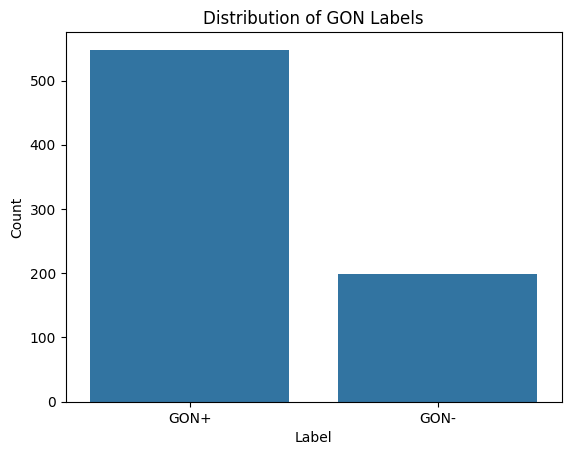


Label distribution:
label
GON+    0.733601
GON-    0.266399
Name: proportion, dtype: float64


In [ ]:
# Distribusi label (GON vs Normal)
plt.figure()
sns.countplot(x="label", data=df)
plt.title("Distribution of GON Labels")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

print("\nLabel distribution:")
print(df["label"].value_counts(normalize=True))

Insight:

Dataset imbalanced (~73% GON+). Artinya:
- Model bisa bias ke glaucoma
- Perlu strategi balancing saat training

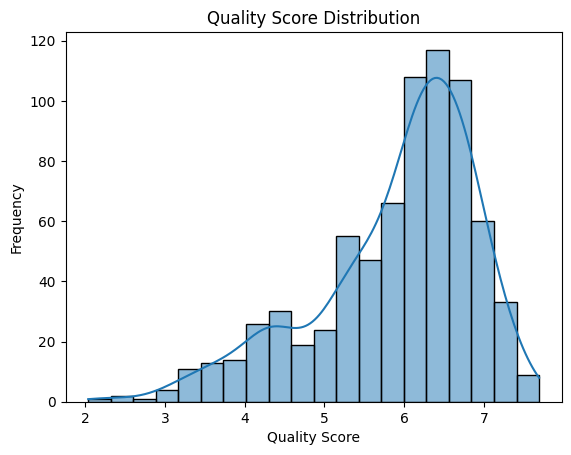

In [ ]:
# Distribusi quality score
plt.figure()
sns.histplot(df["quality_score"], bins=20, kde=True)
plt.title("Quality Score Distribution")
plt.xlabel("Quality Score")
plt.ylabel("Frequency")
plt.show()

Insight:
- Mayoritas kualitas berada di rentang tengah (4-6)
- Sangat sedikit gambar dengan kualitas ekstrem (sangat rendah / sangat tinggi)

Ini penting untuk robustness model (model ketahanan) dan generalisasi ke dunia nyata

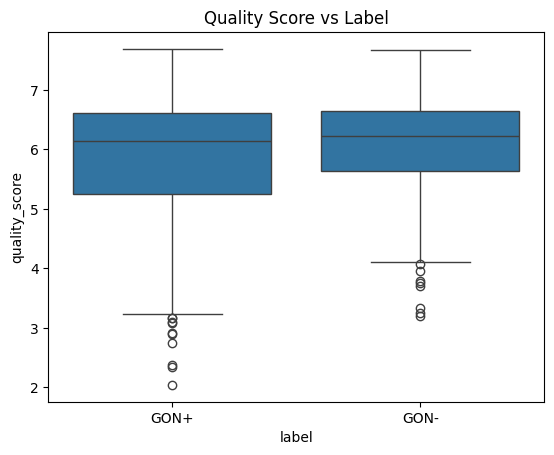

In [ ]:
# Quality vs Label
plt.figure()
sns.boxplot(x="label", y="quality_score", data=df)
plt.title("Quality Score vs Label")
plt.show()

Insight:
- Median dan rentang nilai kualitas pada kedua kelas relatif mirip, menunjukkan bahwa kedua kelas memiliki variasi kualitas yang sebanding.
- Hal ini mengindikasikan bahwa model tidak dapat hanya mengandalkan kualitas gambar untuk membedakan GON+, sehingga perlu belajar fitur struktural dari retina.

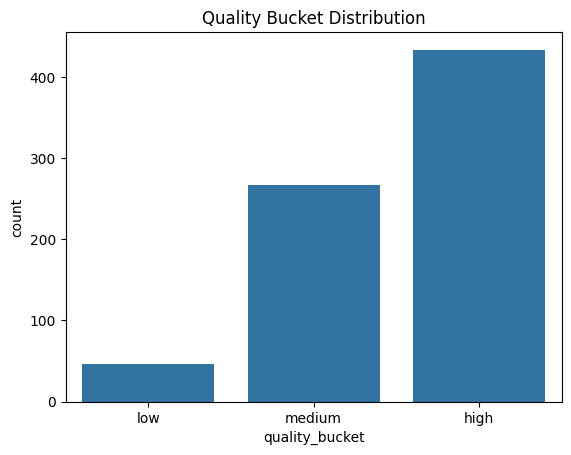


Quality bucket distribution:
quality_bucket
high      434
medium    267
low        46
Name: count, dtype: int64


In [ ]:
# Distribusi quality bucket
plt.figure()
sns.countplot(x="quality_bucket", data=df, order=["low", "medium", "high"])
plt.title("Quality Bucket Distribution")
plt.show()

print("\nQuality bucket distribution:")
print(df["quality_bucket"].value_counts())

Insight:
- Sebagian besar gambar berada pada kategori high quality, diikuti oleh medium, dan hanya sedikit pada kategori low quality.
- ketidakseimbangan ini menunjukkan bahwa dataset didominasi oleh gambar dengan kualitas tinggi, sementara representasi gambar kualitas rendah sangat terbatas.
- akibatnya, model kemungkinan akan lebih optimal pada gambar  berkualitas tinggi, namun kurang tangguh terhadap gambar berkualitas rendah karena jumlah data yang jauh lebih sedikit.

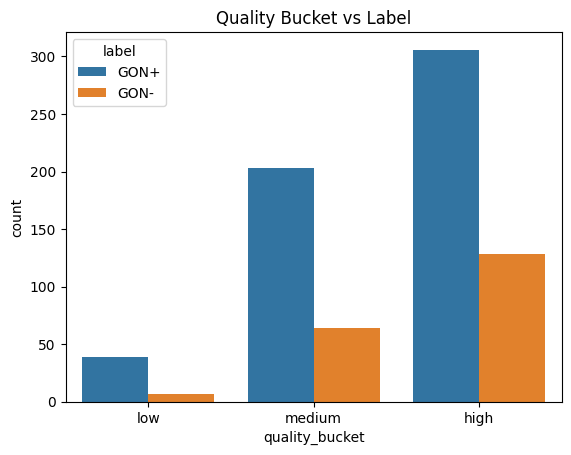

In [ ]:
# Quality bucket vs Label
plt.figure()
sns.countplot(x="quality_bucket", hue="label", data=df, order=["low", "medium", "high"])
plt.title("Quality Bucket vs Label")
plt.show()

Insight:
- kelas GON+ tetap dominan di semua kategori kualitas
- tidak terdapat pergeseran distribusi yang ekstrem antar bucket, sehingga kualitas gambar tidak secara langsung menentukan label
- namun, dominasi kelas GON+ di seluruh bucket tetap mencerminkan class imbalance yang konsisten di seluruh tingkat kualitas

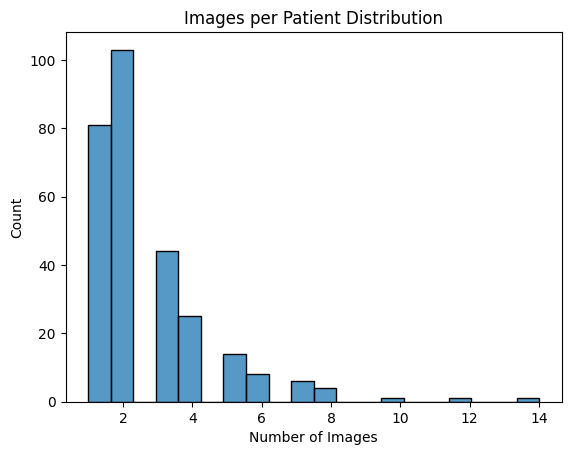


Images per patient summary:
count    288.000000
mean       2.593750
std        1.847372
min        1.000000
25%        1.000000
50%        2.000000
75%        3.000000
max       14.000000
Name: image_name, dtype: float64


In [ ]:
# Jumlah gambar per pasien
images_per_patient = df.groupby("patient_id")["image_name"].count()

plt.figure()
sns.histplot(images_per_patient, bins=20)
plt.title("Images per Patient Distribution")
plt.xlabel("Number of Images")
plt.show()

print("\nImages per patient summary:")
print(images_per_patient.describe())

Insight:
- Banyak pasien memiliki >1 gambar. Artinya, wajib dilakukan "patient-level split". Jika tidak, model akan overstimate performa (model terlihat sangat bagus, tapi sebenarnya tidak)

In [ ]:
# Visualisasi contoh gambar
import cv2
import random

def show_samples(df, label=None, quality_bucket=None, n=5):
    subset = df.copy()

    if label is not None:
        subset = subset[subset["label"] == label]

    if quality_bucket is not None:
        subset = subset[subset["quality_bucket"] == quality_bucket]

    samples = subset.sample(n=min(n, len(subset)), random_state=42)

    plt.figure(figsize=(15, 3))

    for i, (_, row) in enumerate(samples.iterrows()):
        img = cv2.imread(row["image_path"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.title(f'{row["label"]}\nQ={row["quality_score"]:.2f}')
        plt.axis("off")

    plt.show()

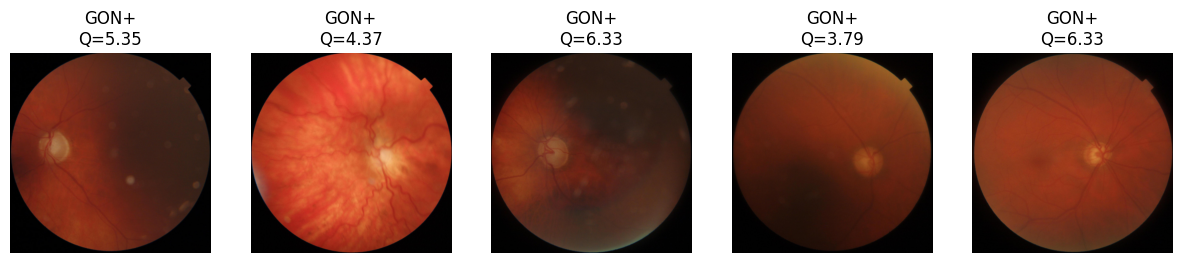

In [ ]:
show_samples(df, label="GON+", n=5)

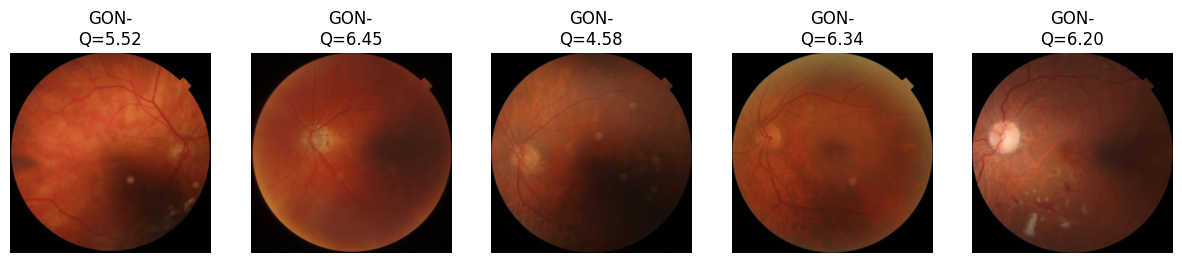

In [ ]:
show_samples(df, label="GON-", n=5)

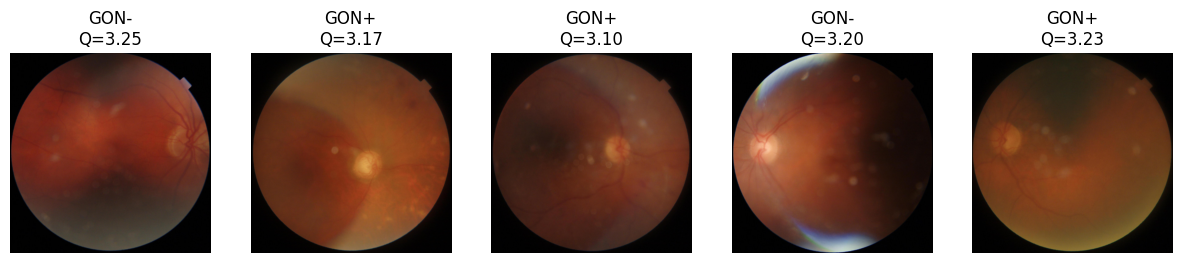

In [ ]:
show_samples(df, quality_bucket="low", n=5)

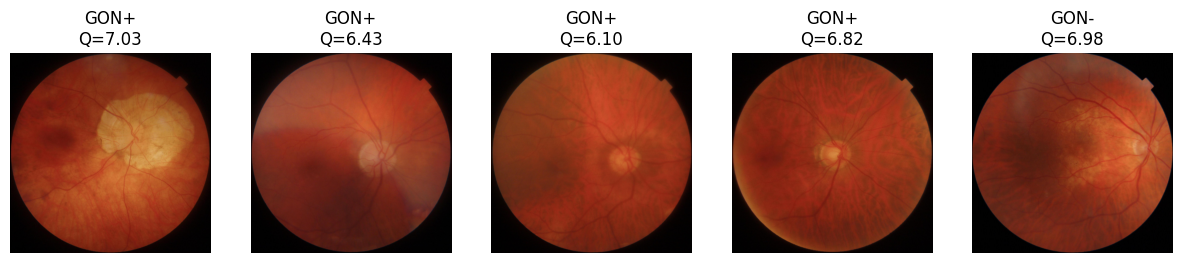

In [ ]:
show_samples(df, quality_bucket="high", n=5)

Highest Quality Image


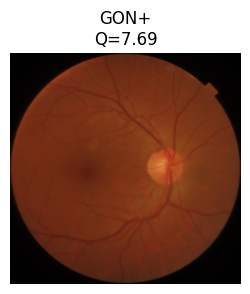


Lowest Quality Image


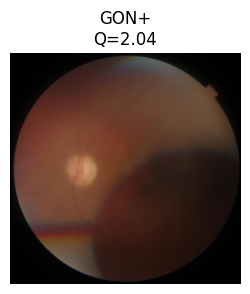

In [ ]:
print("Highest Quality Image")
show_samples(df.sort_values(by="quality_score", ascending=False).head(1), n=1)

print("\nLowest Quality Image")
show_samples(df.sort_values(by="quality_score", ascending=True).head(1), n=1)

Insight:

dari visualisasi ini, akan mulai terlihat:
- perbedaan struktur optic disc
- blur / noise pada kualitas rendah
- variasi pencahayaan
- potensi artefak

hal ini sangat penting untuk:
- desain preprocessing
- interpretasi model nanti

In [ ]:
# Korelasi Sederhana
corr = df[["label_encoded", "quality_score"]].corr()

print("\nCorrelation matrix:")
print(corr)


Correlation matrix:
               label_encoded  quality_score
label_encoded        1.00000       -0.09929
quality_score       -0.09929        1.00000


Insight:
- nilai korelasi antara quality score dan label cenderung rendah (mendekati nol)
- hal ini menunjukkan bahwa kualitas gambar tidak memiliki hubungan linear yang kuat dengan status glaucoma
- dengan demikian, model kemungkinan besar tidak dapat mengandalkakn kualitas gambar saja, tetapi perlu mempelajari fitur visual yang lebih relevan secara klinis

# 3. FEATURE ENGINEERING + DATA SPLIT

In [ ]:
# Load data
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("./data/processed/hygd_preprocessed.csv")

print("Shape:", df.shape)
df.head()

Shape: (747, 8)


,image_name,image_path,patient_id,label,label_encoded,quality_score,quality_score_z,quality_bucket
0,0_0.jpg,/content/drive/MyDrive/Project/idsc 2026/hille...,0,GON+,1,6.18,0.273722,high
1,1_0.jpg,/content/drive/MyDrive/Project/idsc 2026/hille...,1,GON+,1,5.31,-0.590069,medium
2,1_1.jpg,/content/drive/MyDrive/Project/idsc 2026/hille...,1,GON+,1,4.37,-1.523359,medium
3,2_0.jpg,/content/drive/MyDrive/Project/idsc 2026/hille...,2,GON+,1,3.51,-2.377221,low
4,2_1.jpg,/content/drive/MyDrive/Project/idsc 2026/hille...,2,GON+,1,4.24,-1.652431,medium


In [ ]:
# Binary quality flag
df["is_low_quality"] = (df["quality_score"] < 4.0).astype(int)

menandai gambar berkualitas rendah (1=low, 0=tidak) untuk analisis tambahan

In [ ]:
# Patient-level label consistency check
patient_label_counts = df.groupby("patient_id")["label_encoded"].nunique()

mixed_patients = patient_label_counts[patient_label_counts > 1]

print("Patients with mixed labels:", len(mixed_patients))

Patients with mixed labels: 0


mengecek apakah satu pasien punya label campuran.

bagian ini penting karena:

jika satu pasien memiliki label GON+ dan GON-, maka bisa jadi:
- kondisi berubah
- atau labeling ambiguity

hal ini bisa mempengaruhi evaluasi

In [ ]:
# Agregasi patient-level info
patient_df = df.groupby("patient_id").agg({
    "label_encoded": "max",
    "quality_score": "mean",
    "image_name": "count"
}).rename(columns={"image_name": "num_images"})

print(patient_df.head())

            label_encoded  quality_score  num_images
patient_id                                          
0                       1          6.180           1
1                       1          4.840           2
2                       1          3.875           2
3                       1          5.085           2
4                       1          5.250           1


membuat data level pasien (jumlah gambar, rata-rata kualitas, dll) untuk analisis

In [ ]:
# 1. PATIENT-LEVEL SPLIT
# Mengambil patient unique
patients = df["patient_id"].unique()
print("Total patients:", len(patients))

Total patients: 288


In [ ]:
# Stratified split (berdasarkan label)
patient_labels = df.groupby("patient_id")["label_encoded"].max().reset_index()

menentukan label setiap pasien (1 pasien = 1 label)

In [ ]:
# Split train vs temp
train_patients, temp_patients = train_test_split(
    patient_labels,
    test_size=0.30,
    stratify=patient_labels["label_encoded"],
    random_state=42
)

membagi pasien menjadi train 70% dan temp 30%

- temp/temporary merupakan wadah sementara untuk dibagi lagi, karena train_test_split hanya membagi data menjadi 2 bagian

In [ ]:
# Split temp: val + test
val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.50,
    stratify=temp_patients["label_encoded"],
    random_state=42
)

membagi temp menjadi validation 15% dan test 15%

- validation berfungsi untuk menyetel model (tuning) tanpa harus "menyentuh" test set.
- jika hanya memakai train + test, test jadi "terlihat" oleh model secara tidak langsung (data leakage / test contamination)

In [ ]:
# Ambil patient_id
train_ids = train_patients["patient_id"].values
val_ids = val_patients["patient_id"].values
test_ids = test_patients["patient_id"].values

mengambil daftar pasien untuk tiap split

In [ ]:
# Mapping ke dataframe
df["split"] = "unknown"

df.loc[df["patient_id"].isin(train_ids), "split"] = "train"
df.loc[df["patient_id"].isin(val_ids), "split"] = "val"
df.loc[df["patient_id"].isin(test_ids), "split"] = "test"

menentukan setiap gambar masuk ke train / val / test berdasarkan pasiennya

In [ ]:
# Validasi split
print(df["split"].value_counts())

print("\nCheck overlap (should be 0):")
print("Train ∩ Val:", len(set(train_ids) & set(val_ids)))
print("Train ∩ Test:", len(set(train_ids) & set(test_ids)))
print("Val ∩ Test:", len(set(val_ids) & set(test_ids)))

split
train    502
val      124
test     121
Name: count, dtype: int64

Check overlap (should be 0):
Train ∩ Val: 0
Train ∩ Test: 0
Val ∩ Test: 0


memastikan tidak ada pasien yang muncul di lebih dari satu set (no leakage)

In [ ]:
# ANALISIS DISTRIBUSI SPLIT
# Distribusi label per split
print("\nLabel distribution per split:")
print(df.groupby("split")["label_encoded"].value_counts(normalize=True))


Label distribution per split:
split  label_encoded
test   1                0.760331
       0                0.239669
train  1                0.723108
       0                0.276892
val    1                0.750000
       0                0.250000
Name: proportion, dtype: float64


mengecek apakah train/val/test seimbang secara label

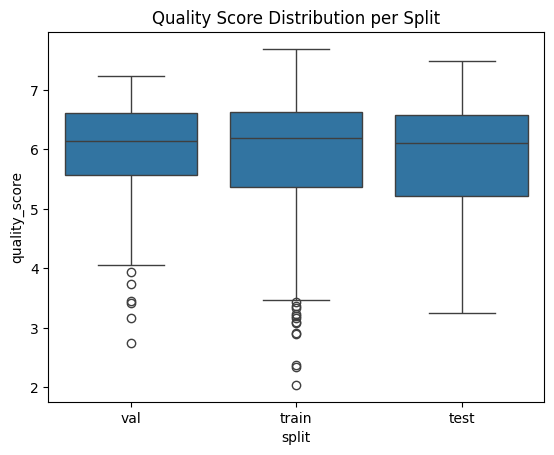

In [ ]:
# Distribusi quality per split
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.boxplot(x="split", y="quality_score", data=df)
plt.title("Quality Score Distribution per Split")
plt.show()

mengecek apakah kualitas gambar tersebar merata di tiap split

In [ ]:
# Jumlah pasien per split
print("\nPatients per split:")
print({
    "train": len(train_ids),
    "val": len(val_ids),
    "test": len(test_ids)
})


Patients per split:
{'train': 201, 'val': 43, 'test': 44}


memastikan proporsi split sesuai (70/15/15)

In [ ]:
# Simpan hasil split
output_path = "./data/processed/hygd_with_split.csv"
df.to_csv(output_path, index=False)

print(f"Saved split dataset to: {output_path}")

Saved split dataset to: ./data/processed/hygd_with_split.csv


# 4. MODEL SELECTION

In [ ]:
# !pip install torch torchvision scikit-learn opencv-python pillow matplotlib pandas

In [ ]:
import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from torchvision import transforms, models

In [ ]:
# Load data split
df = pd.read_csv("./data/processed/hygd_with_split.csv")

print("Shape:", df.shape)
print(df["split"].value_counts())
print(df.head())

Shape: (747, 10)
split
train    502
val      124
test     121
Name: count, dtype: int64
  image_name                                         image_path  patient_id  \
0    0_0.jpg  /content/drive/MyDrive/Project/idsc 2026/hille...           0   
1    1_0.jpg  /content/drive/MyDrive/Project/idsc 2026/hille...           1   
2    1_1.jpg  /content/drive/MyDrive/Project/idsc 2026/hille...           1   
3    2_0.jpg  /content/drive/MyDrive/Project/idsc 2026/hille...           2   
4    2_1.jpg  /content/drive/MyDrive/Project/idsc 2026/hille...           2   

  label  label_encoded  quality_score  quality_score_z quality_bucket  \
0  GON+              1           6.18         0.273722           high   
1  GON+              1           5.31        -0.590069         medium   
2  GON+              1           4.37        -1.523359         medium   
3  GON+              1           3.51        -2.377221            low   
4  GON+              1           4.24        -1.652431         medium   

In [ ]:
# Pisahkan train/val/test
train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df   = df[df["split"] == "val"].reset_index(drop=True)
test_df  = df[df["split"] == "test"].reset_index(drop=True)

print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

Train: (502, 10)
Val  : (124, 10)
Test : (121, 10)


In [ ]:
# Definisikan image transform
IMAGE_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train transform
- resize : menyamakan ukuran
- augmentasi (flip, rotation, dll) : tambah variasi data
- normalize : sesuaikan dengan pretrained model

eval transform
digunakan saat validation dan test

In [ ]:
# Custom Dataset PyTorch
class HYGDDataset(Dataset):
    def __init__(self, dataframe, transform=None, return_metadata=True):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.return_metadata = return_metadata

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image_path = row["image_path"]
        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(row["label_encoded"], dtype=torch.float32)

        if self.return_metadata:
            sample = {
                "image": image,
                "label": label,
                "quality_score": torch.tensor(row["quality_score"], dtype=torch.float32),
                "quality_score_z": torch.tensor(row["quality_score_z"], dtype=torch.float32),
                "patient_id": torch.tensor(row["patient_id"], dtype=torch.long),
                "image_name": row["image_name"],
                "image_path": row["image_path"],   # ✅ tambahkan ini
                "quality_bucket": row["quality_bucket"]
            }
            return sample

        return image, label

In [ ]:
# Buat dataset object
train_dataset = HYGDDataset(train_df, transform=train_transform, return_metadata=True)
val_dataset   = HYGDDataset(val_df, transform=eval_transform, return_metadata=True)
test_dataset  = HYGDDataset(test_df, transform=eval_transform, return_metadata=True)

print("Train dataset size:", len(train_dataset))
print("Val dataset size  :", len(val_dataset))
print("Test dataset size :", len(test_dataset))

Train dataset size: 502
Val dataset size  : 124
Test dataset size : 121


In [ ]:
# Cek satu sample
sample = train_dataset[0]

print(type(sample))
print("Image shape   :", sample["image"].shape)
print("Label         :", sample["label"])
print("Quality score :", sample["quality_score"])
print("Image name    :", sample["image_name"])
print("Quality bucket:", sample["quality_bucket"])

<class 'dict'>
Image shape   : torch.Size([3, 224, 224])
Label         : tensor(1.)
Quality score : tensor(5.3100)
Image name    : 1_0.jpg
Quality bucket: medium


In [ ]:
# Tangani class imbalance
class_counts = train_df["label_encoded"].value_counts().sort_index()
print("Class counts:\n", class_counts)

# weight per class
class_weights = 1.0 / class_counts
print("\nClass weights:\n", class_weights)

# mapping weight ke setiap sample
sample_weights = train_df["label_encoded"].map(class_weights).values
sample_weights = torch.DoubleTensor(sample_weights)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

Class counts:
 label_encoded
0    139
1    363
Name: count, dtype: int64

Class weights:
 label_encoded
0    0.007194
1    0.002755
Name: count, dtype: float64


In [ ]:
# Buat DataLoader
BATCH_SIZE = 16
NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("DataLoaders created successfully.")

DataLoaders created successfully.


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


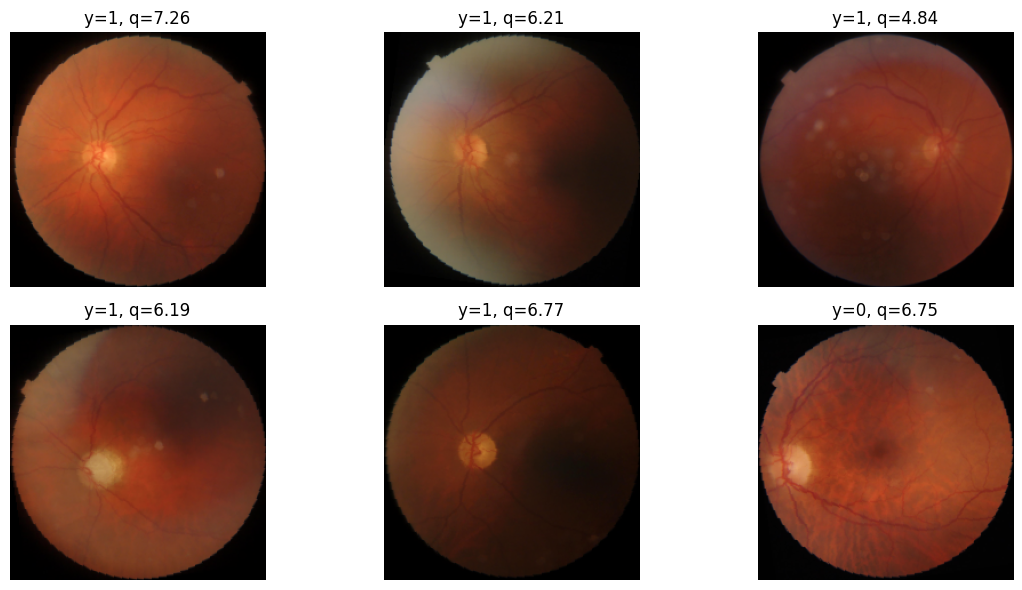

In [ ]:
# Visualisasi batch untuk sanity check
def denormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img_tensor.cpu() * std + mean
    img = torch.clamp(img, 0, 1)
    return img

batch = next(iter(train_loader))
images = batch["image"]
labels = batch["label"]
quality_scores = batch["quality_score"]

plt.figure(figsize=(12, 6))
for i in range(min(6, len(images))):
    plt.subplot(2, 3, i + 1)
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    plt.imshow(img)
    plt.title(f"y={int(labels[i].item())}, q={quality_scores[i].item():.2f}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# Siapkan model EfficientNet-80
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

weights = EfficientNet_B0_Weights.DEFAULT
model = efficientnet_b0(weights=weights)

# Ganti classifier final untuk binary classification
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 1)

model = model.to(device)

print(model)

Using device: cpu
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 135MB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [ ]:
# Opsi model quality-aware (belum dipakai sekarang)
class EfficientNetWithQuality(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)

        self.features = backbone.features
        self.avgpool = backbone.avgpool

        in_features = backbone.classifier[1].in_features

        self.image_fc = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(in_features, 128),
            nn.ReLU()
        )

        self.classifier = nn.Linear(128 + 1, 1)

    def forward(self, x, quality_score_z):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)

        img_feat = self.image_fc(x)

        quality_score_z = quality_score_z.view(-1, 1)
        combined = torch.cat([img_feat, quality_score_z], dim=1)

        out = self.classifier(combined)
        return out

In [ ]:
# Fungsi helper untuk forward pass baseline
def move_batch_to_device(batch, device):
    images = batch["image"].to(device)
    labels = batch["label"].to(device).view(-1, 1)
    quality_score_z = batch["quality_score_z"].to(device).view(-1, 1)
    return images, labels, quality_score_z

In [ ]:
# Sanity check forward pass model
batch = next(iter(train_loader))
images, labels, quality_score_z = move_batch_to_device(batch, device)

with torch.no_grad():
    outputs = model(images)

print("Input shape :", images.shape)
print("Label shape :", labels.shape)
print("Output shape:", outputs.shape)

Input shape : torch.Size([16, 3, 224, 224])
Label shape : torch.Size([16, 1])
Output shape: torch.Size([16, 1])


# 5. TRAINING MODEL

In [ ]:
import copy
import time
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.optim import AdamW

In [ ]:
# Menyiapkan loss function
criterion = nn.BCEWithLogitsLoss()

BCEWithLogitsLoss dipilih karena:
- lebih stabil daripada sigmoid + BCELoss terpisah
- cocok untuk binary output tunggal

In [ ]:
# Menyiapkan optimizer dan scheduler
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

AdamW dipilih karena:
- bagus untuk fine-tuning pretrained networks
- regularisasi lebih baik dari Adam biasa

Menggunakan ReduceLROnPlateau karena:
- sederhana
- cocok ketika validation loss menjadi indikator utama
- membantu model keluar dari stagnasi

In [ ]:
# Fungsi helper untuk hitung akurasi batch
def binary_accuracy_from_logits(logits, labels):
    probs = torch.sigmoid(logits)
    preds = (probs >= 0.5).float()
    acc = (preds == labels).float().mean().item()
    return acc

In [ ]:
# Training function untuk 1 epoch
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    running_acc = 0.0
    total_samples = 0

    for batch in loader:
        images = batch["image"].to(device)
        labels = batch["label"].to(device).view(-1, 1)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        batch_size = images.size(0)
        acc = binary_accuracy_from_logits(outputs, labels)

        running_loss += loss.item() * batch_size
        running_acc += acc * batch_size
        total_samples += batch_size

    epoch_loss = running_loss / total_samples
    epoch_acc = running_acc / total_samples

    return epoch_loss, epoch_acc

In [ ]:
# Validation function untuk 1 epoch
def validate_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    running_acc = 0.0
    total_samples = 0

    all_logits = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            images = batch["image"].to(device)
            labels = batch["label"].to(device).view(-1, 1)

            outputs = model(images)
            loss = criterion(outputs, labels)

            batch_size = images.size(0)
            acc = binary_accuracy_from_logits(outputs, labels)

            running_loss += loss.item() * batch_size
            running_acc += acc * batch_size
            total_samples += batch_size

            all_logits.append(outputs.cpu())
            all_labels.append(labels.cpu())

    epoch_loss = running_loss / total_samples
    epoch_acc = running_acc / total_samples

    all_logits = torch.cat(all_logits, dim=0)
    all_labels = torch.cat(all_labels, dim=0)

    return epoch_loss, epoch_acc, all_logits, all_labels

In [ ]:
# Early stopping class
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.counter = 0
        self.should_stop = False

    def step(self, current_score):
        if self.best_score is None:
            self.best_score = current_score
        elif current_score < self.best_score - self.min_delta:
            self.best_score = current_score
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True

memonitor validation loss, jadi:
makin kecil makin baik

kenapa early stopping?
- karena dataset ini kecil
- kalau training dibiarkan terlalu lama, model bisa hafal train set, dan terlihat bagus di train tapi jelek di data baru

In [ ]:
print(model.classifier[1].weight.abs().mean().item())

0.013701957650482655


In [ ]:
# Training loop utama
NUM_EPOCHS = 15
EARLY_STOPPING_PATIENCE = 5

save_dir = Path("./models")
save_dir.mkdir(parents=True, exist_ok=True)

best_model_path = save_dir / "best_efficientnet_b0_baseline.pth"
history_path = save_dir / "training_history_baseline.csv"

early_stopper = EarlyStopping(patience=EARLY_STOPPING_PATIENCE)

history = {
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "lr": []
}

best_val_loss = float("inf")
best_model_wts = copy.deepcopy(model.state_dict())

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}]")
    print("-" * 40)

    current_lr = optimizer.param_groups[0]["lr"]

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc, val_logits, val_labels = validate_one_epoch(
        model, val_loader, criterion, device
    )

    scheduler.step(val_loss)

    print(f"LR        : {current_lr:.6f}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss  : {val_loss:.4f} | Val Acc  : {val_acc:.4f}")

    history["epoch"].append(epoch + 1)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(current_lr)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, best_model_path)
        print(f"Best model saved to: {best_model_path}")

    early_stopper.step(val_loss)
    if early_stopper.should_stop:
        print("Early stopping triggered.")
        break

elapsed = time.time() - start_time
print(f"\nTraining completed in {elapsed/60:.2f} minutes.")
print(f"Best validation loss: {best_val_loss:.4f}")


Epoch [1/15]
----------------------------------------
LR        : 0.000100
Train Loss: 0.5153 | Train Acc: 0.8088
Val Loss  : 0.2696 | Val Acc  : 0.9355
Best model saved to: models/best_efficientnet_b0_baseline.pth

Epoch [2/15]
----------------------------------------
LR        : 0.000100
Train Loss: 0.2533 | Train Acc: 0.9243
Val Loss  : 0.1065 | Val Acc  : 0.9597
Best model saved to: models/best_efficientnet_b0_baseline.pth

Epoch [3/15]
----------------------------------------
LR        : 0.000100
Train Loss: 0.1422 | Train Acc: 0.9502
Val Loss  : 0.0730 | Val Acc  : 0.9758
Best model saved to: models/best_efficientnet_b0_baseline.pth

Epoch [4/15]
----------------------------------------


KeyboardInterrupt: 

In [ ]:
# Simpan training history
history_df = pd.DataFrame(history)
history_df.to_csv(history_path, index=False)

print(f"Training history saved to: {history_path}")
print(history_df.head())

In [ ]:
# Load best model kembali
model.load_state_dict(torch.load(best_model_path, map_location=device))
model = model.to(device)

print("Best model weights loaded successfully.")

setelah training selesai, harus dipastikan bahwa model yang dipakai nanti adalah best checkpoint, bukan model dari epoch terakhir

In [ ]:
# Plot learning curves
plt.figure()
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(history_df["epoch"], history_df["train_acc"], label="Train Acc")
plt.plot(history_df["epoch"], history_df["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

bagian ini penting untuk melihat:
- overfitting
- underfitting
- training stabil atau tidak

# 6. EVALUASI MODEL

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    classification_report
)

In [ ]:
# Fungsi inference pada test set
def predict_on_loader(model, loader, device):
    model.eval()

    all_logits = []
    all_probs = []
    all_preds = []
    all_labels = []

    all_quality_scores = []
    all_quality_buckets = []
    all_image_names = []
    all_image_paths = []
    all_patient_ids = []

    with torch.no_grad():
        for batch in loader:
            images = batch["image"].to(device)
            labels = batch["label"].to(device).view(-1, 1)

            outputs = model(images)
            probs = torch.sigmoid(outputs)
            preds = (probs >= 0.5).float()

            all_logits.append(outputs.cpu().numpy())
            all_probs.append(probs.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

            all_quality_scores.extend(batch["quality_score"].cpu().numpy().tolist())
            all_quality_buckets.extend(batch["quality_bucket"])
            all_image_names.extend(batch["image_name"])
            all_patient_ids.extend(batch["patient_id"].cpu().numpy().tolist())

            # ambil path dari dataframe batch jika tersedia
            if "image_path" in batch:
                all_image_paths.extend(batch["image_path"])
            else:
                all_image_paths.extend([""] * len(batch["image_name"]))

    results = pd.DataFrame({
        "image_name": all_image_names,
        "image_path": all_image_paths,
        "patient_id": all_patient_ids,
        "quality_score": all_quality_scores,
        "quality_bucket": all_quality_buckets,
        "logit": np.concatenate(all_logits).ravel(),
        "probability": np.concatenate(all_probs).ravel(),
        "prediction": np.concatenate(all_preds).ravel().astype(int),
        "true_label": np.concatenate(all_labels).ravel().astype(int)
    })

    return results

In [ ]:
# Jalankan evaluasi pada test set
test_results = predict_on_loader(model, test_loader, device)

print(test_results.head())
print("\nTest set size:", len(test_results))

In [ ]:
# Fungsi untuk menghitung metrik lengkap
def compute_metrics(df_results):
    y_true = df_results["true_label"].values
    y_pred = df_results["prediction"].values
    y_prob = df_results["probability"].values

    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)  # sensitivity
    f1 = f1_score(y_true, y_pred, zero_division=0)

    # confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)

    metrics = {
        "accuracy": acc,
        "precision": precision,
        "recall_sensitivity": recall,
        "specificity": specificity,
        "f1_score": f1,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }

    return metrics

In [ ]:
# Hitung metrik utama
test_metrics = compute_metrics(test_results)

print("=== TEST METRICS ===")
for k, v in test_metrics.items():
    if isinstance(v, float):
        print(f"{k:20s}: {v:.4f}")
    else:
        print(f"{k:20s}: {v}")

In [ ]:
# Classification report
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(
    test_results["true_label"],
    test_results["prediction"],
    target_names=["GON-", "GON+"],
    zero_division=0
))

In [ ]:
# Confusion Matrix
cm = confusion_matrix(test_results["true_label"], test_results["prediction"])

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred GON-", "Pred GON+"],
            yticklabels=["True GON-", "True GON+"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# ROC Curve
fpr, tpr, _ = roc_curve(test_results["true_label"], test_results["probability"])
roc_auc = roc_auc_score(test_results["true_label"], test_results["probability"])

plt.figure()
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
# Precision-Recall Curve
precision_curve, recall_curve, _ = precision_recall_curve(
    test_results["true_label"],
    test_results["probability"]
)

pr_auc = average_precision_score(
    test_results["true_label"],
    test_results["probability"]
)

plt.figure()
plt.plot(recall_curve, precision_curve, label=f"PR AUC = {pr_auc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

In [ ]:
# Distribusi probabilitas prediksi
plt.figure()
sns.histplot(data=test_results, x="probability", hue="true_label", bins=20, kde=True)
plt.title("Prediction Probability Distribution")
plt.xlabel("Predicted Probability for GON+")
plt.show()

In [ ]:
# Evaluasi per quality bucket
bucket_metrics = []

for bucket in ["low", "medium", "high"]:
    subset = test_results[test_results["quality_bucket"] == bucket].copy()

    if len(subset) == 0:
        continue

    # perlu minimal 2 kelas untuk ROC-AUC
    unique_classes = subset["true_label"].nunique()

    metrics = {
        "quality_bucket": bucket,
        "n_samples": len(subset),
        "accuracy": accuracy_score(subset["true_label"], subset["prediction"]),
        "precision": precision_score(subset["true_label"], subset["prediction"], zero_division=0),
        "recall_sensitivity": recall_score(subset["true_label"], subset["prediction"], zero_division=0),
        "f1_score": f1_score(subset["true_label"], subset["prediction"], zero_division=0)
    }

    cm_bucket = confusion_matrix(subset["true_label"], subset["prediction"], labels=[0, 1])
    tn, fp, fn, tp = cm_bucket.ravel()
    metrics["specificity"] = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    if unique_classes == 2:
        metrics["roc_auc"] = roc_auc_score(subset["true_label"], subset["probability"])
        metrics["pr_auc"] = average_precision_score(subset["true_label"], subset["probability"])
    else:
        metrics["roc_auc"] = np.nan
        metrics["pr_auc"] = np.nan

    bucket_metrics.append(metrics)

bucket_metrics_df = pd.DataFrame(bucket_metrics)
print(bucket_metrics_df)

In [ ]:
# Visualisasi performa per quality bucket
metrics_to_plot = ["accuracy", "recall_sensitivity", "specificity", "f1_score"]

for metric in metrics_to_plot:
    plt.figure()
    sns.barplot(data=bucket_metrics_df, x="quality_bucket", y=metric, order=["low", "medium", "high"])
    plt.ylim(0, 1)
    plt.title(f"{metric} by Quality Bucket")
    plt.ylabel(metric)
    plt.xlabel("Quality Bucket")
    plt.show()

In [ ]:
# Analisis error: false positive dan false negative
false_positive = test_results[
    (test_results["true_label"] == 0) & (test_results["prediction"] == 1)
].copy()

false_negative = test_results[
    (test_results["true_label"] == 1) & (test_results["prediction"] == 0)
].copy()

true_positive = test_results[
    (test_results["true_label"] == 1) & (test_results["prediction"] == 1)
].copy()

true_negative = test_results[
    (test_results["true_label"] == 0) & (test_results["prediction"] == 0)
].copy()

print("False Positive:", len(false_positive))
print("False Negative:", len(false_negative))
print("True Positive :", len(true_positive))
print("True Negative :", len(true_negative))

In [ ]:
# Visualisasi contoh prediksi
import cv2
import random

def show_prediction_samples(results_df, title, n=5):
    subset = results_df.sample(n=min(n, len(results_df)), random_state=42)

    plt.figure(figsize=(15, 3))
    for i, (_, row) in enumerate(subset.iterrows()):
        img = cv2.imread(row["image_name"] if "image_path" not in row.index else row["image_path"])
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1, min(n, len(subset)), i + 1)
        plt.imshow(img)
        plt.title(
            f'T={row["true_label"]}, P={row["prediction"]}\n'
            f'Prob={row["probability"]:.2f}, Q={row["quality_score"]:.2f}'
        )
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

In [ ]:
# Simpan hasil evaluasi
results_dir = Path("./results")
results_dir.mkdir(parents=True, exist_ok=True)

test_results.to_csv(results_dir / "test_predictions_baseline.csv", index=False)
bucket_metrics_df.to_csv(results_dir / "test_metrics_by_quality_bucket.csv", index=False)

metrics_df = pd.DataFrame([test_metrics])
metrics_df.to_csv(results_dir / "test_metrics_baseline.csv", index=False)

print("Evaluation results saved.")

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from PIL import Image

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        self.forward_hook = self.target_layer.register_forward_hook(self.save_activation)
        self.backward_hook = self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_heatmap(self, input_tensor):
        self.model.eval()
        self.model.zero_grad()

        output = self.model(input_tensor)
        output = output.squeeze()
        output.backward()

        gradients = self.gradients.detach().cpu().numpy()[0]
        activations = self.activations.detach().cpu().numpy()[0]

        weights = np.mean(gradients, axis=(1, 2))
        heatmap = np.zeros(activations.shape[1:], dtype=np.float32)

        for i, w in enumerate(weights):
            heatmap += w * activations[i]

        heatmap = np.maximum(heatmap, 0)

        if np.max(heatmap) != 0:
            heatmap /= np.max(heatmap)

        return heatmap

    def remove_hooks(self):
        self.forward_hook.remove()
        self.backward_hook.remove()


def visualize_gradcam(img_path, heatmap):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (224, 224))

    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_color = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_color, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    superimposed_img = cv2.addWeighted(img_resized, 0.6, heatmap_color, 0.4, 0)

    return img_resized, superimposed_img

In [ ]:
# 1. Set model eval
model.eval()

# 2. Inisialisasi GradCAM
target_layer = model.features[-1]
grad_cam = GradCAM(model, target_layer)

# 3. Ambil 1 contoh gambar GON+ dari test set
sample_row = test_df[test_df["label_encoded"] == 1].iloc[0]
img_path = sample_row["image_path"]

# 4. Preprocessing gambar
img_pil = Image.open(img_path).convert("RGB")
input_tensor = eval_transform(img_pil).unsqueeze(0).to(device)

# 5. Generate heatmap
heatmap = grad_cam.generate_heatmap(input_tensor)
original, result = visualize_gradcam(img_path, heatmap)

# 6. Plot
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(original)
plt.title(f"Asli: {sample_row['label']} (Q: {sample_row['quality_score']:.2f})")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(result)
plt.title("Grad-CAM: Fokus AI pada Saraf Mata")
plt.axis("off")

plt.tight_layout()
plt.show()

# 7. Hapus hooks
grad_cam.remove_hooks()

# Quality Weighted Inference

In [ ]:
import os
import cv2
import torch
import numpy as np
import textwrap
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

def apply_clahe_for_inference(image_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    img = cv2.merge((l, a, b))
    image_clahe = cv2.cvtColor(img, cv2.COLOR_LAB2RGB)
    return Image.fromarray(image_clahe)

def get_weighted_clinical_recommendation(image_path, model, df, threshold=4.0):
    image_name = os.path.basename(image_path)

    # Ambil Skor Kualitas dari Dataframe
    try:
        # Mencari baris berdasarkan nama file
        row = df[df['image_name'] == image_name].iloc[0]
        quality_score = float(row['quality_score'])
    except:
        return f"Error: Data {image_name} tidak ditemukan.", None, None

    # 2. Preprocessing & Prediksi AI
    image_pil = apply_clahe_for_inference(image_path)
    input_tensor = eval_transform(image_pil).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(input_tensor)
        # Pakai sigmoid karena output-nya biner
        prob_gon_plus = torch.sigmoid(outputs).item()

    # 3. QUALITY-WEIGHTED LOGIC (Inovasi Matematika)
    # Normalisasi kualitas ke skala 0-1
    quality_factor = quality_score / 10.0
    # Final Score = Probabilitas AI * Faktor Kualitas
    weighted_conf = prob_gon_plus * quality_factor

    # Penentuan Label Prediksi
    predicted_label = "Glaucoma (GON+)" if prob_gon_plus >= 0.5 else "Normal (GON-)"

    # 4. Clinical Recommendation Logic
    if quality_score < threshold:
        msg = (f"HASIL: {predicted_label}. TAPI Kualitas Gambar Rendah ({quality_score:.2f}). "
               f"Weighted Confidence: {weighted_conf:.2f}. "
               f"SARAN: Ambil foto ulang demi keamanan diagnosa.")
    else:
        if prob_gon_plus >= 0.5:
            msg = (f"DIAGNOSA: Glaucoma (GON+). Weighted Confidence: {weighted_conf:.2f} "
                   f"(Kualitas Baik: {quality_score:.2f}). Segera rujuk ke spesialis.")
        else:
            msg = (f"DIAGNOSA: Normal (GON-). Weighted Confidence: {weighted_conf:.2f}. "
                   f"Kualitas Gambar: {quality_score:.2f}. Risiko Rendah.")

    return f"{msg}", predicted_label, weighted_conf


In [ ]:
# Periksa untuk gambar berkualitas rendah
QUALITY_THRESHOLD = 4.0
low_q_data = test_df[test_df['quality_score'] < QUALITY_THRESHOLD]

if not low_q_data.empty:
    sample = low_q_data.iloc[0]
    hasil_teks, _, _ = get_weighted_clinical_recommendation(sample['image_path'], model, df, threshold=QUALITY_THRESHOLD)

    # Visualisasi
    plt.figure(figsize=(8, 6))
    img_raw = cv2.cvtColor(cv2.imread(sample['image_path']), cv2.COLOR_BGR2RGB)
    plt.imshow(img_raw)
    plt.title("\n".join(textwrap.wrap(hasil_teks, width=60)), fontsize=11, color='orange', fontweight='bold')
    plt.axis('off')
    plt.show()